# Модель STRDP синаптической пластичности


## 0. Реализация модели

Подключение библиотек:

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings(action='once')
print(plt.style.available)
plt.style.use('seaborn-v0_8-paper')
sns.set_style("white")

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


Модель LIF нейрона:

In [52]:
class LIF_neuron:
    def __init__(self, type, tau_m=20.0, v_rest=-65.0, v_thresh=-10.0, v_reset=-65.0, r_m=1.0, dt=1.0):
        self.type = type
        
        self.tau_m = tau_m
        self.v_rest = v_rest
        self.v_thresh = v_thresh
        self.v_reset = v_reset
        self.r_m = r_m
        self.dt = dt

        # current state
        self.v = v_rest
        self.I = 0.0
        self.spike = False

        # saving results
        self.trace_v = []

    # update state on dt + refactoring period
    def update(self, I_inj=0.0):
        self.I = I_inj

        #else
        dv = (-(self.v - self.v_rest) + self.r_m * self.I) * (self.dt / self.tau_m)

        self.v += dv

        # spike generation
        self.spike = False
        if self.v >= self.v_thresh:
            self.spike = True
            self.v = self.v_reset
        
        # saving voltage
        self.trace_v.append(self.v)
        
    def get_voltage(self):
        return self.v

    def has_spiked(self):
        return self.spike


Модель синапса с STRDP-правилом:

In [53]:
class STRDP_Synapse:
    def __init__(self, pre_neuron, post_neuron, weight=0.5, tau_s=5.0, tau_plus=7.0, tau_minus=2.7,
                w_max=1.0, w_min=0.0):
        self.pre = pre_neuron
        self.post = post_neuron
        self.weight = weight
        self.tau_s = tau_s
        self.mu = 0.0005

        self.I_syn = 0.0

        self.tau_plus = tau_plus
        self.tau_minus = tau_minus
        self.w_max = w_max
        self.w_min = w_min

        # trace
        self.trace_pre = 0.0
        self.trace_post = 0.0

        # history for graphics
        self.weight_history = [weight]
        self.trace_pre_history = []
        self.trace_post_history = []

        self.dt = self.pre.dt

        # for the method from article
        self.nu = 0.05
        self.alpha = 10
        self.b_minus = 75.0

        # last spikes
        self.last_pre_spike = -1e6
        self.last_post_spike = -1e6

    def strdp_method(self, t):
        spike_pre = self.pre.has_spiked()
        spike_post = self.post.has_spiked()

        if spike_pre:
        #    if self.last_post_spike != -1e6 and self.last_post_spike < t:
        #        dt = t - self.last_post_spike
#
        #        F_plus = self.nu * (self.w_max - self.weight)
        #        ltp = F_plus * np.exp(-dt / self.tau_plus)
#
        #        F_minus = self.nu * self.alpha * self.weight
        #        ltd = F_minus / (1 + np.exp(self.b_minus - dt / self.tau_minus))
#
        #        self.weight += (ltp - ltd)


        #     # if exists post before pre
        #     if self.last_post_spike != -1e6 and self.last_post_spike < t:
        #         dt = self.last_post_spike - t 
        #         # LTD
        #         F_minus = self.nu * self.alpha * self.weight
        #         ltd = F_minus / (1 + np.exp(- dt / self.tau_minus))
        #         self.weight -= ltd * self.dt
            self.last_pre_spike = t

        if spike_post:
            # if exists pre before post
            if self.last_pre_spike != -1e6 and self.last_pre_spike < t:
                dt = t - self.last_pre_spike
                # LTP
                F_plus = self.nu * (self.w_max - self.weight)
                ltp = F_plus * np.exp(-dt / self.tau_plus)

                F_minus = self.nu * self.alpha * self.weight
                ltd = F_minus / (1 + np.exp(self.b_minus - dt / self.tau_minus))

                self.weight += (ltp - ltd)

        self.weight = np.clip(self.weight, self.w_min, self.w_max)
        self.weight_history.append(self.weight)

    def update(self, t):
        # if new spike from pre
        # if self.pre.spike:
        #     total_spike_input = 500.0
        # else:
        #     total_spike_input = 0.0

        # update synaptic I
        # dI_syn = (-self.I_syn + total_spike_input) * (self.dt / self.tau_s)
        # self.I_syn += dI_syn

        self.strdp_method(t)

    def get_weight(self):
        return self.weight
    
    def get_current(self):
        return self.I_syn

Сеть для генерации эксперимента:

In [54]:
class Network:
    def __init__(self, Tmax, scale, n_pre, n_post, I_pre, I_post, weight_matrix):
        self.Tmax = Tmax
        self.scale = scale
        self.n_pre = n_pre
        self.n_post = n_post
        self.I_pre = I_pre
        self.I_post = I_post
        self.weight_matrix = weight_matrix

        # time
        self.T = np.linspace(0, Tmax, Tmax * scale)
        self.dt = self.T[1] - self.T[0]

        # neurons
        self.pre_neurons = np.array([LIF_neuron(type='pre', dt=self.dt) for _ in range(n_pre)], dtype=object)
        self.post_neurons = np.array([LIF_neuron(type='post', dt=self.dt) for _ in range(n_post)], dtype=object)

        # synapses
        self.synapses = np.empty((n_pre, n_post), dtype=object)
        for i in range(n_pre):
            for j in range(n_post):
                self.synapses[i, j] = STRDP_Synapse(
                    self.pre_neurons[i], 
                    self.post_neurons[j], 
                    weight=weight_matrix[i, j]
                )

        # data saving
        self.V_pre_history = np.zeros((len(self.T), n_pre))
        self.V_post_history = np.zeros((len(self.T), n_post))
        self.weights_history = np.zeros((len(self.T), n_pre, n_post))
        self.I_syn_history = np.zeros((len(self.T), n_post))

        self.pre_spikes_history = np.zeros((len(self.T), n_pre), dtype=bool)
        self.post_spikes_history = np.zeros((len(self.T), n_post), dtype=bool)

    def run_simulation(self):
        for step, t in enumerate(self.T):
            # pre
            for i, neuron in enumerate(self.pre_neurons):
                neuron.update(I_inj=self.I_pre[i](t))
                self.V_pre_history[step, i] = neuron.get_voltage()
                self.pre_spikes_history[step, i] = neuron.has_spiked()

            # post
            for j, neuron in enumerate(self.post_neurons):
                neuron.update(I_inj=self.I_post[j](t))
                self.V_post_history[step, j] = neuron.get_voltage()
                self.post_spikes_history[step, j] = neuron.has_spiked()
                self.I_syn_history[step, j] = self.I_post[j](t)

            # synapses
            for i in range(self.n_pre):
                for j in range(self.n_post):
                    self.synapses[i, j].update(t)
                    self.weights_history[step, i, j] = self.synapses[i, j].get_weight()

    def get_results(self):
        return {
            'time': self.T,
            'V_pre': self.V_pre_history,
            'V_post': self.V_post_history,
            'weights': self.weights_history,
            'I_syn': self.I_syn_history,
            'pre_spikes': self.get_spike_trains(self.pre_neurons),
            'post_spikes': self.get_spike_trains(self.post_neurons)
        }

    def get_spike_trains(self, neurons):
        spike_trains = []
        for neuron_idx, neuron in enumerate(neurons):
            if neuron.type == 'pre':
                spike_times = self.T[self.pre_spikes_history[:, neuron_idx]]
            else:
                spike_times = self.T[self.post_spikes_history[:, neuron_idx]]
            spike_trains.append(spike_times)
        return spike_trains

    def get_final_weights(self):
        final_weights = np.zeros((self.n_pre, self.n_post))

        for i in range(self.n_pre):
            for j in range(self.n_post):
                final_weights[i, j] = self.synapses[i, j].get_weight()
        return final_weights

## 1. Эксперимент с различными частотами (проверка работы STRDP - обновления весов)

Частота на пресинаптическом больше чем на постсинапическом:

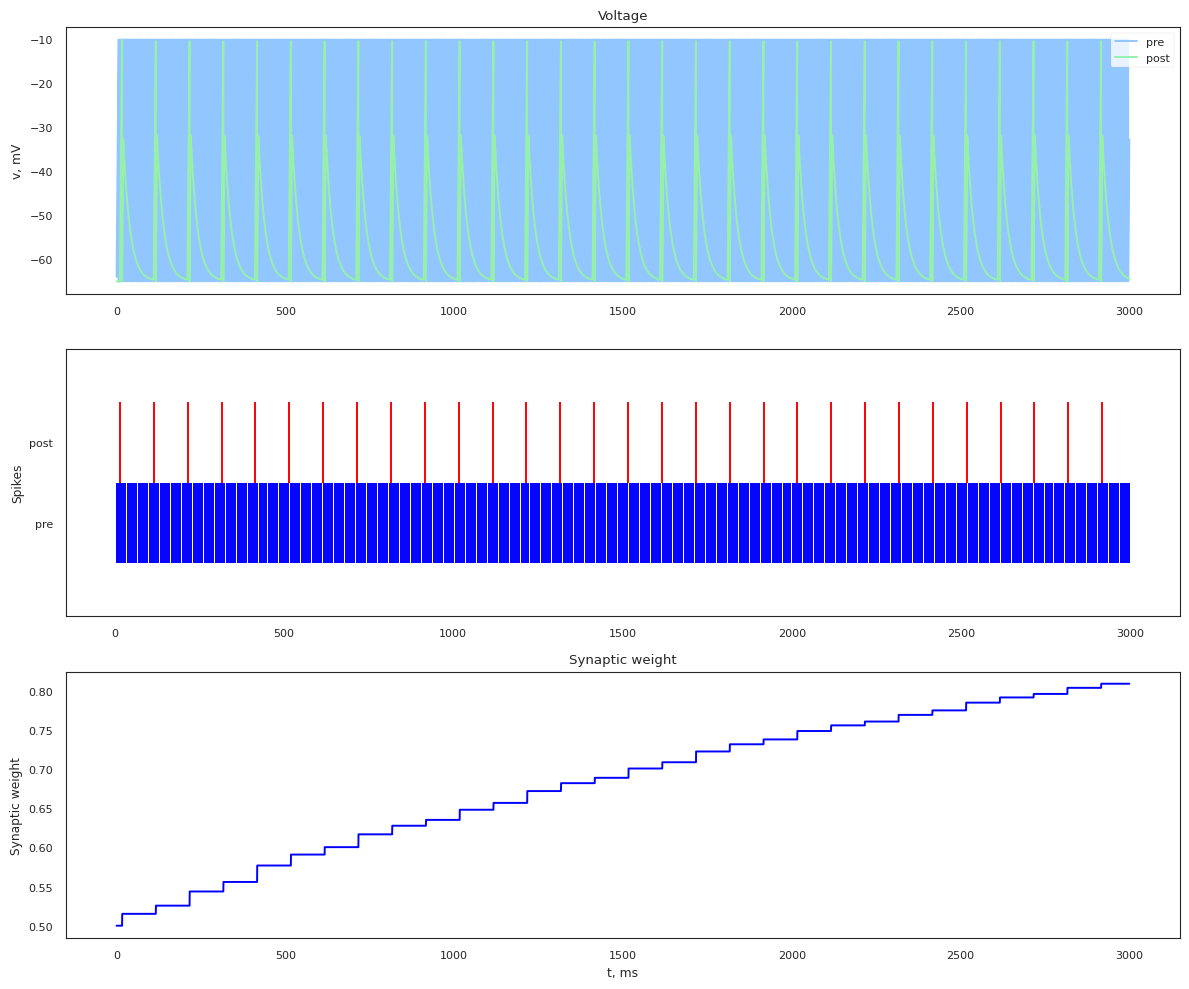

Initial weight: 0.5
Final weight: 0.8088642168356042
Difference: 0.3089
Presynaptic spikes: 461
Postsynaptic spikes: 30


In [50]:
Tmax = 3000
scale = 10
n_pre = 1
n_post = 1

def I_pre(t):
    return 200.0 if (t % 10.0) < 10.0 else 0.0

def I_post(t):
    return 200.0 if ((t - 10.0) % 100.0) < 10.0 else 0.0

weight_matrix = np.array([[0.5]])

I_pre_func = [I_pre]
I_post_func = [I_post]
network = Network(Tmax, scale, n_pre, n_post, I_pre_func, I_post_func, weight_matrix)

network.run_simulation()
results = network.get_results()


# visualising
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(results['time'], results['V_pre'][:, 0], label='pre')
plt.plot(results['time'], results['V_post'][:, 0], label='post')
plt.ylabel('v, mV')
plt.legend()
plt.title('Voltage')

# spikes
plt.subplot(3, 1, 2)
pre_spike_times = results['pre_spikes'][0]
post_spike_times = results['post_spikes'][0]
plt.eventplot([pre_spike_times, post_spike_times], colors=['blue', 'red'])
plt.ylabel('Spikes')
plt.yticks([0, 1], ['pre', 'post'])

# synaptic weight
plt.subplot(3, 1, 3)
plt.plot(results['time'], results['weights'][:, 0, 0], color='blue')
plt.ylabel('Synaptic weight')
plt.xlabel('t, ms')
plt.title('Synaptic weight')

plt.tight_layout()
plt.show()

# results
final_weight = network.get_final_weights()[0, 0]
print(f"Initial weight: {weight_matrix[0, 0]}")
print(f"Final weight: {final_weight}")
print(f"Difference: {final_weight - weight_matrix[0, 0]:.4f}")

# spikes
pre_spike_count = len(results['pre_spikes'][0])
post_spike_count = len(results['post_spikes'][0])
print(f"Presynaptic spikes: {pre_spike_count}")
print(f"Postsynaptic spikes: {post_spike_count}")

Частота на постсинаптическом больше чем на пресинаптическом:

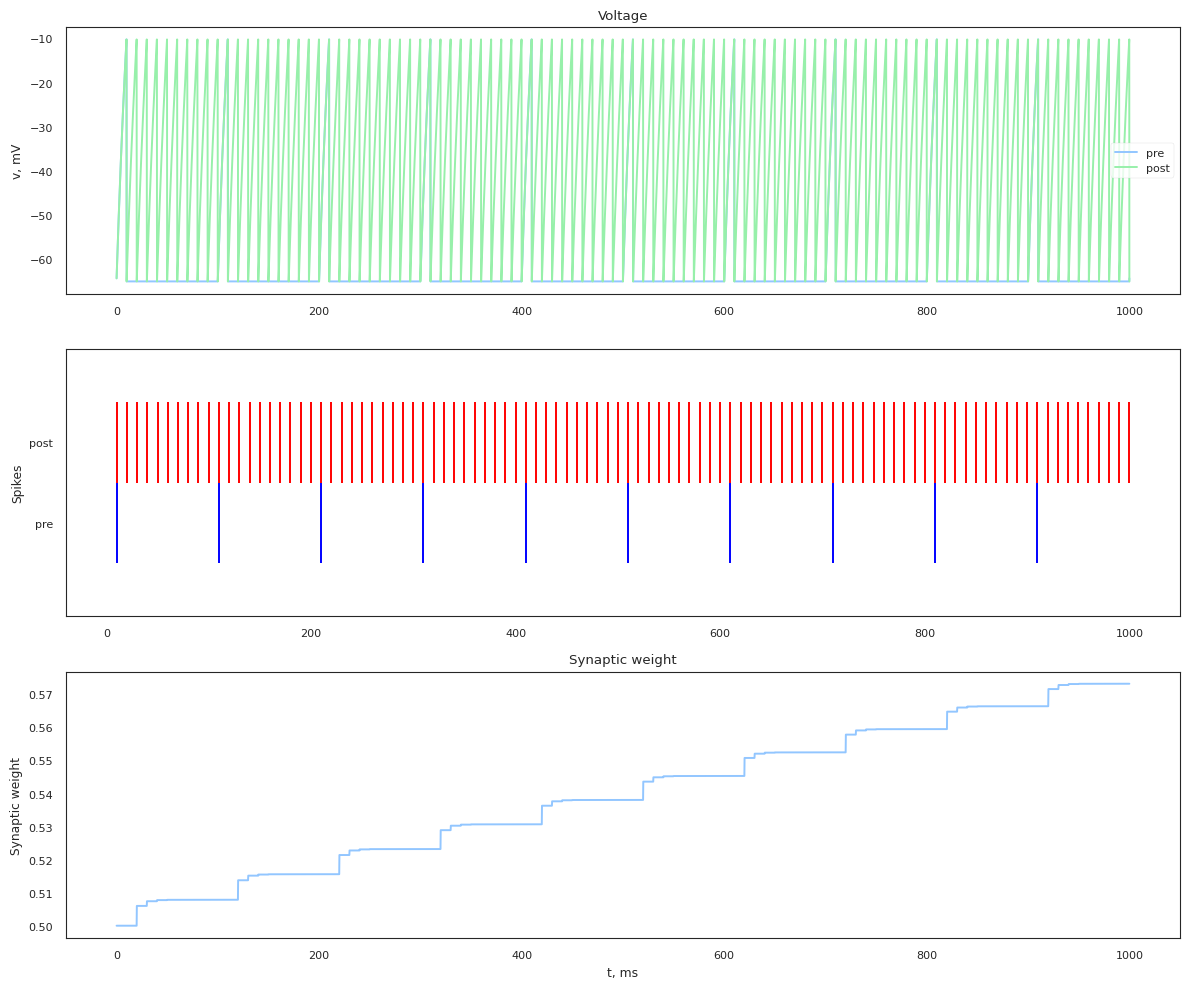

Initial weight: 0.5
Final weight: 0.5732159970294627
Difference: 0.0732
Presynaptic spikes: 10
Postsynaptic spikes: 100


In [41]:
Tmax = 1000
scale = 10
n_pre = 1
n_post = 1

def I_pre(t):
    return 140.0 if (t % 100.0) < 10.0 else 0.0

def I_post(t):
    return 140.0 if ((t + 10.0) % 5.0) < 10.0 else 0.0

weight_matrix = np.array([[0.5]])

I_pre_func = [I_pre]
I_post_func = [I_post]
network = Network(Tmax, scale, n_pre, n_post, I_pre_func, I_post_func, weight_matrix)

network.run_simulation()
results = network.get_results()


# visualising
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(results['time'], results['V_pre'][:, 0], label='pre')
plt.plot(results['time'], results['V_post'][:, 0], label='post')
plt.ylabel('v, mV')
plt.legend()
plt.title('Voltage')

# spikes
plt.subplot(3, 1, 2)
pre_spike_times = results['pre_spikes'][0]
post_spike_times = results['post_spikes'][0]
plt.eventplot([pre_spike_times, post_spike_times], colors=['blue', 'red'])
plt.ylabel('Spikes')
plt.yticks([0, 1], ['pre', 'post'])

# synaptic weight
plt.subplot(3, 1, 3)
plt.plot(results['time'], results['weights'][:, 0, 0])
plt.ylabel('Synaptic weight')
plt.xlabel('t, ms')
plt.title('Synaptic weight')

plt.tight_layout()
plt.show()

# results
final_weight = network.get_final_weights()[0, 0]
print(f"Initial weight: {weight_matrix[0, 0]}")
print(f"Final weight: {final_weight}")
print(f"Difference: {final_weight - weight_matrix[0, 0]:.4f}")

# spikes
pre_spike_count = len(results['pre_spikes'][0])
post_spike_count = len(results['post_spikes'][0])
print(f"Presynaptic spikes: {pre_spike_count}")
print(f"Postsynaptic spikes: {post_spike_count}")

## 2. Зависимость от длительности временных промежутков

Δt = -50 ms, Δw = -0.0000000008958412345272
Δt = -49 ms, Δw = -0.0000000013046674296469
Δt = -48 ms, Δw = -0.0000000018958503100741
Δt = -47 ms, Δw = -0.0000000027512814249064
Δt = -46 ms, Δw = -0.0000000039895537984336
Δt = -45 ms, Δw = -0.0000000057824203203438
Δt = -44 ms, Δw = -0.0000000083786315108192
Δt = -43 ms, Δw = -0.0000000121384611251329
Δt = -42 ms, Δw = -0.0000000175837123195244
Δt = -41 ms, Δw = -0.0000000254701448820782
Δt = -40 ms, Δw = -0.0000000368923775972974
Δt = -39 ms, Δw = -0.0000000534358257087142
Δt = -38 ms, Δw = -0.0000000773967635536721
Δt = -37 ms, Δw = -0.0000001121010581583981
Δt = -36 ms, Δw = -0.0000001623658139604522
Δt = -35 ms, Δw = -0.0000002351680069567763
Δt = -34 ms, Δw = -0.0000003406129133742830
Δt = -33 ms, Δw = -0.0000004933367496184893
Δt = -32 ms, Δw = -0.0000007145381994977384
Δt = -31 ms, Δw = -0.0000010349207831272800
Δt = -30 ms, Δw = -0.0000014989544095400653
Δt = -29 ms, Δw = -0.0000021710474884528708
Δt = -28 ms, Δw = -0.00000314448

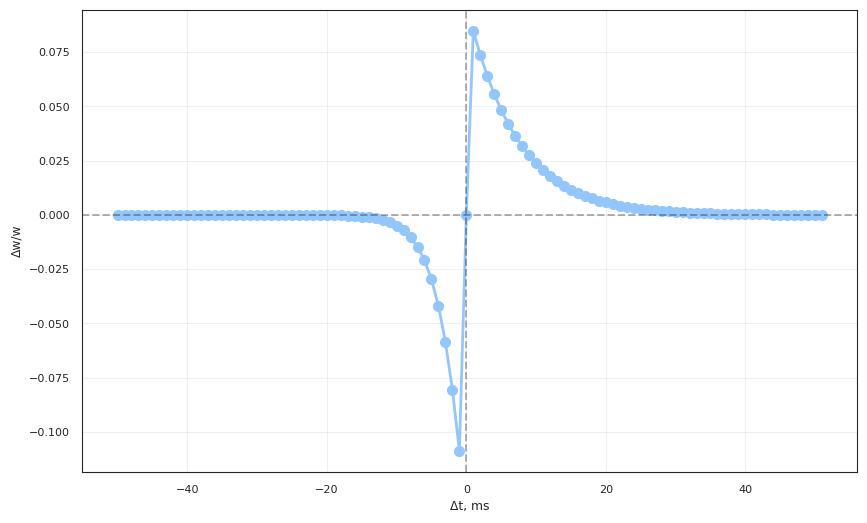

In [55]:

dt_values = np.arange(-50, 52, )
weight_changes = []
initial_weight = 0.5

for dt in dt_values:
    Tmax = 500
    scale = 10
    n_pre = 1
    n_post = 1

    def I_pre(t):
        return 2000.0 if ((t >= 100.0) and (t < 101.0)) or ((t >= 300.0) and (t < 301.0)) else 0.0

    def I_post(t):
        return 2000.0 if ((t >= (100.0 + dt)) and (t < (101.0 + dt))) or ((t >= (300.0 + dt)) and (t < (301.0 + dt))) else 0.0

    weight_matrix = np.array([[initial_weight]])

    I_pre_func = [I_pre]
    I_post_func = [I_post]
    
    network = Network(Tmax, scale, n_pre, n_post, I_pre_func, I_post_func, weight_matrix)
    network.run_simulation()
    
    final_weight = network.get_final_weights()[0, 0]
    weight_changes.append((final_weight - initial_weight) / 0.5)
    print(f"Δt = {dt} ms, Δw = {final_weight - initial_weight:.22f}")

plt.figure(figsize=(10, 6))
plt.plot(dt_values, weight_changes, 'o-', linewidth=2, markersize=8)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('Δt, ms')
plt.ylabel('Δw/w')
plt.title('')
plt.grid(True, alpha=0.3)
plt.show()


# STDP протокол

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings(action='once')
print(plt.style.available)
plt.style.use('seaborn-v0_8-paper')
sns.set_style("white")



['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [57]:
class LIF_neuron:
    def __init__(self, type, tau_m=20.0, v_rest=-65.0, v_thresh=-10.0, v_reset=-65.0, r_m=1.0, dt=1.0):
        self.type = type
        
        self.tau_m = tau_m
        self.v_rest = v_rest
        self.v_thresh = v_thresh
        self.v_reset = v_reset
        self.r_m = r_m
        self.dt = dt

        # current state
        self.v = v_rest
        self.I = 0.0
        self.spike = False

        # saving results
        self.trace_v = []

    # update state on dt + refactoring period
    def update(self, I_inj=0.0):
        self.I = I_inj

        #else
        dv = (-(self.v - self.v_rest) + self.r_m * self.I) * (self.dt / self.tau_m)

        self.v += dv

        # spike generation
        self.spike = False
        if self.v >= self.v_thresh:
            self.spike = True
            self.v = self.v_reset
        
        # saving voltage
        self.trace_v.append(self.v)
        
    def get_voltage(self):
        return self.v

    def has_spiked(self):
        return self.spike


STDP протокол:


In [58]:
class STDP_Synapse:
    def __init__(self, pre_neuron, post_neuron, weight=0.5, tau_s=5.0, tau_plus=7.0, tau_minus=5.0,
                w_max=1.0, w_min=0.0):
        self.pre = pre_neuron
        self.post = post_neuron
        self.weight = weight
        self.tau_s = tau_s
        self.mu = 0.0005

        self.I_syn = 0.0

        self.tau_plus = tau_plus
        self.tau_minus = tau_minus
        self.w_max = w_max
        self.w_min = w_min

        # trace
        self.trace_pre = 0.0
        self.trace_post = 0.0

        # history for graphics
        self.weight_history = [weight]
        self.trace_pre_history = []
        self.trace_post_history = []

        self.dt = self.pre.dt

        # for the method from article
        self.nu = 0.05
        self.alpha = 2.5
        self.b_minus = 75.0

        # last spikes
        self.last_pre_spike = -1e6
        self.last_post_spike = -1e6

    def stdp_method(self, t):
        spike_pre = self.pre.has_spiked()
        spike_post = self.post.has_spiked()

        if spike_pre:
            # if exists post before pre
            if self.last_post_spike != -1e6 and self.last_post_spike < t:
                 dt = self.last_post_spike - t 
                 # LTD
                 F_minus = self.nu * self.alpha * self.weight
                 ltd = F_minus / (1 + np.exp(- dt / self.tau_minus))
                 self.weight -= ltd

            self.last_pre_spike = t

        if spike_post:
            # if exists pre before post
            if self.last_pre_spike != -1e6 and self.last_pre_spike < t:
                dt = t - self.last_pre_spike
                # LTP
                F_plus = self.nu * (self.w_max - self.weight)
                ltp = F_plus * np.exp(-dt / self.tau_plus)
                self.weight += ltp

            self.last_post_spike = t

        self.weight = np.clip(self.weight, self.w_min, self.w_max)
        self.weight_history.append(self.weight)

    def update(self, t):
        # if new spike from pre
        # if self.pre.spike:
        #     total_spike_input = 500.0
        # else:
        #     total_spike_input = 0.0

        # update synaptic I
        # dI_syn = (-self.I_syn + total_spike_input) * (self.dt / self.tau_s)
        # self.I_syn += dI_syn

        self.stdp_method(t)

    def get_weight(self):
        return self.weight
    
    def get_current(self):
        return self.I_syn

Сеть:

In [59]:
class Network:
    def __init__(self, Tmax, scale, n_pre, n_post, I_pre, I_post, weight_matrix):
        self.Tmax = Tmax
        self.scale = scale
        self.n_pre = n_pre
        self.n_post = n_post
        self.I_pre = I_pre
        self.I_post = I_post
        self.weight_matrix = weight_matrix

        # time
        self.T = np.linspace(0, Tmax, Tmax * scale)
        self.dt = self.T[1] - self.T[0]

        # neurons
        self.pre_neurons = np.array([LIF_neuron(type='pre', dt=self.dt) for _ in range(n_pre)], dtype=object)
        self.post_neurons = np.array([LIF_neuron(type='post', dt=self.dt) for _ in range(n_post)], dtype=object)

        # synapses
        self.synapses = np.empty((n_pre, n_post), dtype=object)
        for i in range(n_pre):
            for j in range(n_post):
                self.synapses[i, j] = STDP_Synapse(
                    self.pre_neurons[i], 
                    self.post_neurons[j], 
                    weight=weight_matrix[i, j]
                )

        # data saving
        self.V_pre_history = np.zeros((len(self.T), n_pre))
        self.V_post_history = np.zeros((len(self.T), n_post))
        self.weights_history = np.zeros((len(self.T), n_pre, n_post))
        self.I_syn_history = np.zeros((len(self.T), n_post))

        self.pre_spikes_history = np.zeros((len(self.T), n_pre), dtype=bool)
        self.post_spikes_history = np.zeros((len(self.T), n_post), dtype=bool)

    def run_simulation(self):
        for step, t in enumerate(self.T):
            # pre
            for i, neuron in enumerate(self.pre_neurons):
                neuron.update(I_inj=self.I_pre[i](t))
                self.V_pre_history[step, i] = neuron.get_voltage()
                self.pre_spikes_history[step, i] = neuron.has_spiked()

            # post
            for j, neuron in enumerate(self.post_neurons):
                neuron.update(I_inj=self.I_post[j](t))
                self.V_post_history[step, j] = neuron.get_voltage()
                self.post_spikes_history[step, j] = neuron.has_spiked()
                self.I_syn_history[step, j] = self.I_post[j](t)

            # synapses
            for i in range(self.n_pre):
                for j in range(self.n_post):
                    self.synapses[i, j].update(t)
                    self.weights_history[step, i, j] = self.synapses[i, j].get_weight()

    def get_results(self):
        return {
            'time': self.T,
            'V_pre': self.V_pre_history,
            'V_post': self.V_post_history,
            'weights': self.weights_history,
            'I_syn': self.I_syn_history,
            'pre_spikes': self.get_spike_trains(self.pre_neurons),
            'post_spikes': self.get_spike_trains(self.post_neurons)
        }

    def get_spike_trains(self, neurons):
        spike_trains = []
        for neuron_idx, neuron in enumerate(neurons):
            if neuron.type == 'pre':
                spike_times = self.T[self.pre_spikes_history[:, neuron_idx]]
            else:
                spike_times = self.T[self.post_spikes_history[:, neuron_idx]]
            spike_trains.append(spike_times)
        return spike_trains

    def get_final_weights(self):
        final_weights = np.zeros((self.n_pre, self.n_post))

        for i in range(self.n_pre):
            for j in range(self.n_post):
                final_weights[i, j] = self.synapses[i, j].get_weight()
        return final_weights

Эксперимент:

Δt = -50 ms, Δw = -0.0000056633653774396109
Δt = -48 ms, Δw = -0.0000084492334179731010
Δt = -46 ms, Δw = -0.0000126053451989238674
Δt = -44 ms, Δw = -0.0000188054839592166623
Δt = -42 ms, Δw = -0.0000280545280940680541
Δt = -40 ms, Δw = -0.0000418508802261241541
Δt = -38 ms, Δw = -0.0000624282498452588541
Δt = -36 ms, Δw = -0.0000931151515561889909
Δt = -34 ms, Δw = -0.0001388685289556157443
Δt = -32 ms, Δw = -0.0002070638400204494189
Δt = -30 ms, Δw = -0.0003086604140239979088
Δt = -28 ms, Δw = -0.0004599104690027333575
Δt = -26 ms, Δw = -0.0006848436129078816492
Δt = -24 ms, Δw = -0.0010188306076694408908
Δt = -22 ms, Δw = -0.0015135895144222644149
Δt = -20 ms, Δw = -0.0022439868980740351745
Δt = -18 ms, Δw = -0.0033167756415636295841
Δt = -16 ms, Δw = -0.0048807358122936461697
Δt = -14 ms, Δw = -0.0071360942441908714606
Δt = -12 ms, Δw = -0.0103380148079507128145
Δt = -10 ms, Δw = -0.0147841830929548723184
Δt = -8 ms, Δw = -0.0207717764248618319556
Δt = -6 ms, Δw = -0.0285106191192

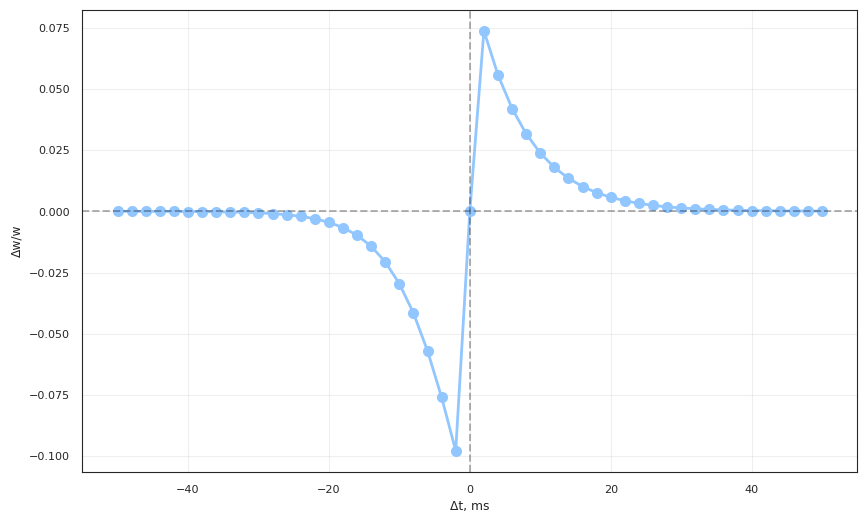

In [60]:

dt_values = np.arange(-50, 52, 2)
weight_changes = []
initial_weight = 0.5

for dt in dt_values:
    Tmax = 500
    scale = 10
    n_pre = 1
    n_post = 1

    def I_pre(t):
        return 2000.0 if ((t >= 100.0) and (t < 101.0)) or ((t >= 300.0) and (t < 301.0)) else 0.0

    def I_post(t):
        return 2000.0 if ((t >= (100.0 + dt)) and (t < (101.0 + dt))) or ((t >= (300.0 + dt)) and (t < (301.0 + dt))) else 0.0

    weight_matrix = np.array([[initial_weight]])

    I_pre_func = [I_pre]
    I_post_func = [I_post]
    
    network = Network(Tmax, scale, n_pre, n_post, I_pre_func, I_post_func, weight_matrix)
    network.run_simulation()
    
    final_weight = network.get_final_weights()[0, 0]
    weight_changes.append((final_weight - initial_weight) / 0.5)
    print(f"Δt = {dt} ms, Δw = {final_weight - initial_weight:.22f}")

plt.figure(figsize=(10, 6))
plt.plot(dt_values, weight_changes, 'o-', linewidth=2, markersize=8)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('Δt, ms')
plt.ylabel('Δw/w')
plt.title('')
plt.grid(True, alpha=0.3)
plt.show()
